In [ ]:
from typing import TypedDict, Annotated, Optional
from langgraph.graph import add_messages, StateGraph, END
from dotenv import load_dotenv
from langchain_community.tools. tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4
import json
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage, ToolMessage
load_dotenv()

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
)

# model = ChatOllama(
#     model="deepseek-v3.1:671b-cloud",
#     base_url="http://127.0.0.1:11434",
#     temperature=0,
# )

response = model.invoke("Give me a joke about cat")
response

AIMessage(content="Why don't cats play poker in the jungle?\n\nToo many cheetahs.", additional_kwargs={}, response_metadata={'model': 'deepseek-v3.1:671b-cloud', 'created_at': '2026-03-13T16:44:40.552051388Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3408152003, 'load_duration': None, 'prompt_eval_count': 10, 'prompt_eval_duration': None, 'eval_count': 17, 'eval_duration': None, 'logprobs': None, 'model_name': 'deepseek-v3.1:671b-cloud'}, id='run-45022f7a-370d-47af-8bb9-9fbd4a2b69d6-0', usage_metadata={'input_tokens': 10, 'output_tokens': 17, 'total_tokens': 27})

In [9]:
search_tool = TavilySearchResults(max_results=3)

search_tool.invoke("What is the weather in Bangolora?")

[{'title': 'Bangalore weather in March 2026 | India: How hot?',
  'url': 'https://www.weather2travel.com/india/bangalore/march/',
  'content': "weather2travel.com - travel deals for your holiday in the sun\n\n Home\n Asia / Southern Asia\n India\n Bangalore\n Weather in March\n\n# Bangalore weather in March 2026\n\nExpect  daytime maximum temperatures of 33°C in Bangalore, India in March and high heat and humidity based on long-term weather averages. There are 9 hours of sunshine per day on average.\n\n 33°C max day temperature\n 9 hours of sunshine per day\n 1 day with some rainfall\n 19°C min night temperature\n 12 hours of daylight per day in March in Bangalore12\n\n  12 hours of daylight per day\n High heat & humidity in March in BangaloreH\n\n  High heat & humidity\n 10 mm monthly rainfall in March in Bangalore10\n\n  10 mm of monthly rainfall\n UV (maximum) index 11+ (Extreme) in March in Bangalore11\n\n  11+ (Extreme) UV index [...] ### How hot is it in Bangalore in March?\n\nDa

In [10]:
tools = [search_tool]

memory = MemorySaver()

llm_with_tools = model.bind_tools(tools=tools)

response = llm_with_tools.invoke("What is the weather in Bagalore?")
response

AIMessage(content="I'll search for the current weather in Bangalore for you.", additional_kwargs={}, response_metadata={'model': 'deepseek-v3.1:671b-cloud', 'created_at': '2026-03-13T16:45:02.787914385Z', 'done': True, 'done_reason': 'stop', 'total_duration': 17554979035, 'load_duration': None, 'prompt_eval_count': 186, 'prompt_eval_duration': None, 'eval_count': 34, 'eval_duration': None, 'logprobs': None, 'model_name': 'deepseek-v3.1:671b-cloud'}, id='run-edfe2154-d454-4539-9399-5d0b1a022245-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather Bangalore India today'}, 'id': '47cf891c-de73-4e9d-9588-43fed0c079cd', 'type': 'tool_call'}], usage_metadata={'input_tokens': 186, 'output_tokens': 34, 'total_tokens': 220})

In [11]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


async def model(state: State, config: RunnableConfig):
    result = await llm_with_tools.ainvoke(state["messages"], config=config)
    return {
        "messages": [result], 
    }


async def tools_router(state: State):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    
async def tool_node(state: State, config: RunnableConfig):
    tool_calls = state["messages"][-1].tool_calls

    tool_messages =[]

    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]

        if tool_name == "tavily_search_results_json":
            search_results = await search_tool.ainvoke(tool_args, config=config)

            tool_message = ToolMessage(
                content=str(search_results),
                tool_call_id=tool_id,
                name=tool_name
            )
        
            tool_messages.append(tool_message)
    
    return {"messages": tool_messages}

graph_builder = StateGraph(State)
graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)
graph_builder.set_entry_point("model")

graph_builder.add_conditional_edges("model", tools_router)
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

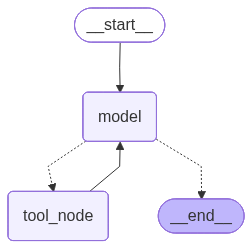

In [12]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [13]:
config = {
    "configurable": {
        "thread_id": 4
    }
}

response = await graph.ainvoke({
    "messages": [HumanMessage(content="When next SpaceX launch?")]
}, config=config)

response

{'messages': [HumanMessage(content='When next SpaceX launch?', additional_kwargs={}, response_metadata={}, id='bdeeca8c-ae96-4284-b8fe-33bac25ab431'),
  AIMessage(content="I'll search for the latest information about the next SpaceX launch.", additional_kwargs={}, response_metadata={'model': 'deepseek-v3.1:671b-cloud', 'created_at': '2026-03-13T16:45:16.674860166Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7343980599, 'load_duration': None, 'prompt_eval_count': 183, 'prompt_eval_duration': None, 'eval_count': 35, 'eval_duration': None, 'logprobs': None, 'model_name': 'deepseek-v3.1:671b-cloud'}, id='run-6e7e23f8-9203-45e7-8f74-23b532d05d3c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'next SpaceX launch date schedule'}, 'id': 'c3309f14-1271-4710-b50c-d530e70cecee', 'type': 'tool_call'}], usage_metadata={'input_tokens': 183, 'output_tokens': 35, 'total_tokens': 218}),
  ToolMessage(content='[{\'title\': \'Launch Schedule\', \'url\': \'https://sp

In [14]:
config_1 = {
    "configurable": {
        "thread_id": 8
    }
}
k=0
# Use async for to iterate over the async generator
async for event in graph.astream_events({
    "messages": [HumanMessage(content="When is the next spacex launch?")],
}, config=config_1, version="v2"):
    print(event)


{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='When is the next spacex launch?', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '697ba5b6-a181-46fa-a063-7673a4f19331', 'metadata': {'thread_id': 8}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='When is the next spacex launch?', additional_kwargs={}, response_metadata={}, id='cd88d371-8e91-466a-941d-07a5661bf08f')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': 'f4b1b204-d7cf-4259-a23b-d2848d0782a4', 'metadata': {'thread_id': 8, 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:697024a9-f05e-b556-9263-2a2adcc1f75f'}, 'parent_ids': ['697ba5b6-a181-46fa-a063-7673a4f19331']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='When is the next spa